# **Lab 2 Spacial Analysis**

**Task 1** **พื้นที่ศึกษา จังหวัดเชียงใหม่**

เหตุผลที่เลือก : เชียงใหม่เป็นจังหวัดที่มีความหลากหลายทางภูมิประเทศ ทั้งพื้นที่ภูเขา ป่าไม้ พื้นที่เกษตร และชุมชนเมือง อีกทั้งยังเป็นพื้นที่ที่เผชิญปัญหาไฟป่า หมอกควัน และสภาพแห้งแล้งในช่วงฤดูแล้งเป็นประจำ โดยเฉพาะช่วงปลายฤดูหนาวถึงต้นฤดูร้อน ซึ่งทำให้เชียงใหม่เหมาะสมสำหรับการวิเคราะห์เชิงพื้นที่ด้วยข้อมูลดาวเทียมเพื่อศึกษาสภาพพืชพรรณ ความชื้น และการเปลี่ยนแปลงของพื้นที่เสี่ยงไฟป่า

คำถามวิจัย :
1. ในช่วงฤดูแล้งของจังหวัดเชียงใหม่ พื้นที่ใดมีแนวโน้มแห้งแล้งสูงจากข้อมูลดัชนีพืชพรรณและความชื้น
2. พื้นที่ใดอาจมีความเสี่ยงต่อการเกิดไฟป่ามากกว่า เมื่อพิจารณาจากสภาพพืชพรรณ ความชื้น และความสัมพันธ์ระหว่างดัชนีต่าง ๆ
3. เมื่อเปรียบเทียบ 2 ช่วงเวลา พื้นที่ใดมีการเปลี่ยนแปลงของสภาพพืชพรรณและความชื้นอย่างเด่นชัด

**Task 2 ดาวเทียมที่ใช้และช่วงเวลา**

**Sentinel-2**

เนื่องจากภาพจาก Sentinel-2 มีความละเอียดเชิงพื้นที่ 10 เมตร สำหรับหลายแบนด์สำคัญ เช่น Red, NIR และ SWIR บางส่วน เหมาะสำหรับการคำนวณดัชนี เช่น NDVI, NDMI, NBR เหมาะกับการวิเคราะห์ระดับจังหวัด ให้รายละเอียดมากกว่า Landsat 8/9 ที่มีความละเอียด 30 เมตร จึงเหมาะกับการดูพื้นที่เสี่ยงไฟป่าและพื้นที่แห้งแล้งที่กระจายตัวไม่สม่ำเสมอมีรอบการบันทึกข้อมูลถี่ ทำให้มีโอกาสได้ภาพปลอดเมฆมากขึ้นเมื่อทำ composite

**ช่วงเวลาที่ศึกษาจะเลือกเปรียบเทียบ 2 ช่วงเวลาในฤดูแล้ง**
ช่วงที่ 1: 1 มกราคม 2024 – 15 กุมภาพันธ์ 2024

ช่วงที่ 2: 16 มีนาคม 2024 – 30 เมษายน 2024

เนื่องจากแม้เป็นช่วงฤดูแล้งทั้ง 2 ช่วงเวลาแต่ช่วงแรกในพื้นที่อามีความชื้นสะสมจากปลายฤดูหนาวอยู่บ้าง และช่วงหลังเป็นช่วงที่สภาพอากาศร้อนและแห้งมากขึ้น ซึ่งมักสัมพันธ์กับความเสี่ยงไฟป่าที่สูงขึ้น การเปรียบเทียบ 2 ช่วงนี้จะช่วยให้เห็นการเปลี่ยนแปลงของพืชพรรณและความชื้นได้ชัด

**เกณฑ์การกรองเมฆ**

**CLOUDY_PIXEL_PERCENTAGE < 20**

เนื่องจาก ถ้ากรองเข้มเกินไป เช่น < 5% อาจเหลือภาพน้อยเกินไป แต่ถ้ากรองหลวมเกินไป เช่น < 50% อาจมีเมฆรบกวน composite ดังนั้น ค่า 20% เป็นจุดสมดุลระหว่างคุณภาพภาพกับจำนวนภาพที่ใช้ได้



In [3]:
!pip install geemap earthengine-api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.3 MB/s eta 0:00:00


In [4]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

# Authenticate and initialize
try:
    ee.Initialize(project='ee-natthanichap')
except:
    ee.Authenticate()
    ee.Initialize(project='ee-natthanichap')

In [5]:
# Load FAO GAUL admin boundaries กำหนดพื้นที่ศึกษา
gaul_lvl1 = ee.FeatureCollection("FAO/GAUL/2015/level1")
gaul_lvl2 = ee.FeatureCollection("FAO/GAUL/2015/level2")

# Select Chiang Mai province
chiangmai = gaul_lvl1.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Thailand'),
        ee.Filter.eq('ADM1_NAME', 'Chiang Mai')
    )
)

# Select districts in Chiang Mai for zonal statistics
chiangmai_districts = gaul_lvl2.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Thailand'),
        ee.Filter.eq('ADM1_NAME', 'Chiang Mai')
    )
)

roi = chiangmai.geometry()

print("Province features:", chiangmai.size().getInfo())
print("District features:", chiangmai_districts.size().getInfo())

Province features: 1
District features: 22


In [6]:
# Time periods กำหนดช่วงเวลา
start1 = '2024-01-01'
end1   = '2024-02-15'

start2 = '2024-03-16'
end2   = '2024-04-30'

In [7]:
 # Mask เมฆและเพิ่มดัชนี
def mask_s2_clouds(image):
    # Sentinel-2 SR Harmonized
    scl = image.select('SCL')

    # Mask out cloud shadow, clouds, cirrus
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))

    return image.updateMask(mask).copyProperties(image, image.propertyNames())

def add_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndmi = image.normalizedDifference(['B8', 'B11']).rename('NDMI')
    nbr  = image.normalizedDifference(['B8', 'B12']).rename('NBR')
    return image.addBands([ndvi, ndmi, nbr])

In [8]:
# โหลดข้อมูล Sentinel-2
s2_1 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(roi)
    .filterDate(start1, end1)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
    .map(add_indices)
)

s2_2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(roi)
    .filterDate(start2, end2)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
    .map(add_indices)
)

print("Images in period 1:", s2_1.size().getInfo())
print("Images in period 2:", s2_2.size().getInfo())

Images in period 1: 97
Images in period 2: 107


In [10]:
# แสดงแผนที่
Map = geemap.Map(center=[18.8, 98.9], zoom=8)

rgb_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000
}

ndvi_vis = {
    'min': -0.2,
    'max': 0.8,
    'palette': ['brown', 'yellow', 'green']
}

ndmi_vis = {
    'min': -0.5,
    'max': 0.5,
    'palette': ['red', 'orange', 'yellow', 'lightblue', 'blue']
}

nbr_vis = {
    'min': -0.5,
    'max': 0.8,
    'palette': ['black', 'red', 'orange', 'yellow', 'green']
}

Map.addLayer(comp1, rgb_vis, 'RGB Period 1')
Map.addLayer(comp2, rgb_vis, 'RGB Period 2')
Map.addLayer(comp1.select('NDVI'), ndvi_vis, 'NDVI Period 1')
Map.addLayer(comp2.select('NDVI'), ndvi_vis, 'NDVI Period 2')
Map.addLayer(comp1.select('NDMI'), ndmi_vis, 'NDMI Period 1')
Map.addLayer(comp2.select('NDMI'), ndmi_vis, 'NDMI Period 2')
Map.addLayer(comp1.select('NBR'), nbr_vis, 'NBR Period 1')
Map.addLayer(comp2.select('NBR'), nbr_vis, 'NBR Period 2')
Map.addLayer(chiangmai.style(color='cyan', fillColor='00000000'), {}, 'Chiang Mai boundary')

Map

Map(center=[18.8, 98.9], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…

In [9]:
# สร้าง composite
comp1 = s2_1.median().clip(roi)
comp2 = s2_2.median().clip(roi)

In [11]:
# เปรียบเทียบการเปลี่ยนแปลง 2 ช่วงเวลา
ndvi_diff = comp2.select('NDVI').subtract(comp1.select('NDVI')).rename('NDVI_diff')
ndmi_diff = comp2.select('NDMI').subtract(comp1.select('NDMI')).rename('NDMI_diff')
nbr_diff  = comp2.select('NBR').subtract(comp1.select('NBR')).rename('NBR_diff')

diff_vis = {
    'min': -0.3,
    'max': 0.3,
    'palette': ['red', 'white', 'green']
}

Map2 = geemap.Map(center=[18.8, 98.9], zoom=8)
Map2.addLayer(ndvi_diff, diff_vis, 'NDVI Change')
Map2.addLayer(ndmi_diff, diff_vis, 'NDMI Change')
Map2.addLayer(nbr_diff, diff_vis, 'NBR Change')
Map2.addLayer(chiangmai.style(color='black', fillColor='00000000'), {}, 'Boundary')
Map2

Map(center=[18.8, 98.9], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…

In [12]:
# Zonal Statistics ระดับอำเภอ
# Mean NDVI / NDMI / NBR by district for period 2
district_stats = comp2.select(['NDVI', 'NDMI', 'NBR']).reduceRegions(
    collection=chiangmai_districts,
    reducer=ee.Reducer.mean(),
    scale=10
)

# Convert to pandas DataFrame
stats_dict = district_stats.getInfo()

rows = []
for f in stats_dict['features']:
    props = f['properties']
    rows.append({
        'District': props.get('ADM2_NAME'),
        'NDVI_mean': props.get('NDVI'),
        'NDMI_mean': props.get('NDMI'),
        'NBR_mean': props.get('NBR')
    })

df_stats = pd.DataFrame(rows)
df_stats = df_stats.sort_values(by='NDMI_mean')
df_stats.head(10)

,District,NDVI_mean,NDMI_mean,NBR_mean
7,Hot,0.489356,-0.052749,0.147886
4,Doi Tao,0.473615,-0.032614,0.170796
18,San Pa Tong,0.462871,-0.017012,0.181307
13,Muang Chiang Mai,0.430175,0.008433,0.179410
0,Chai Prakan,0.518699,0.014099,0.244570
19,San Sai,0.484122,0.015859,0.224507
6,Hang Dong,0.501272,0.019648,0.236194
2,Chom Thong,0.537335,0.020782,0.244435
20,Saraphi,0.477567,0.023491,0.212605
1,Chiang Dao,0.521508,0.029729,0.264516


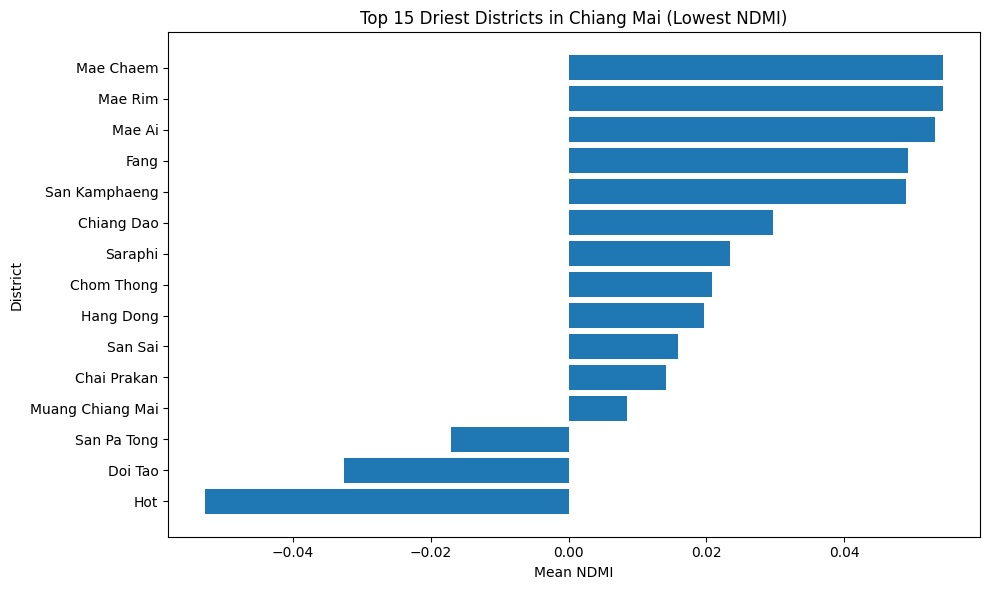

In [13]:
plt.figure(figsize=(10,6))
df_plot = df_stats.dropna().sort_values('NDMI_mean').head(15)
plt.barh(df_plot['District'], df_plot['NDMI_mean'])
plt.xlabel('Mean NDMI')
plt.ylabel('District')
plt.title('Top 15 Driest Districts in Chiang Mai (Lowest NDMI)')
plt.tight_layout()
plt.show()

         NDVI     NDMI
NDVI  1.00000  0.88416
NDMI  0.88416  1.00000


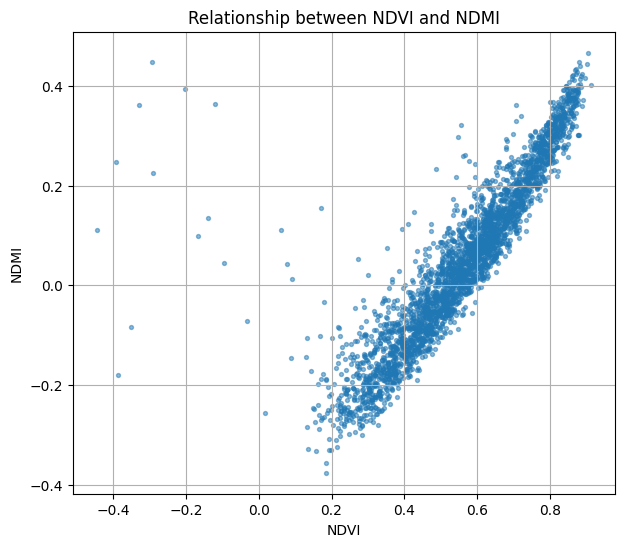

In [14]:
# Sample pixels for scatter plot วิเคราะห์ความสัมพันธ์ NDVI กับ NDMI
samples = comp2.select(['NDVI', 'NDMI']).sample(
    region=roi,
    scale=100,
    numPixels=3000,
    geometries=False
)

sample_dict = samples.getInfo()

data = []
for f in sample_dict['features']:
    p = f['properties']
    if 'NDVI' in p and 'NDMI' in p:
        data.append([p['NDVI'], p['NDMI']])

df_corr = pd.DataFrame(data, columns=['NDVI', 'NDMI'])

print(df_corr.corr())

plt.figure(figsize=(7,6))
plt.scatter(df_corr['NDVI'], df_corr['NDMI'], s=8, alpha=0.5)
plt.xlabel('NDVI')
plt.ylabel('NDMI')
plt.title('Relationship between NDVI and NDMI')
plt.grid(True)
plt.show()

In [15]:
# คำนวณพื้นที่เสี่ยงแห้งแล้ง โดยกำหนดว่า พื้นที่แห้งแล้ง = NDMI < 0
dry_mask = comp2.select('NDMI').lt(0).selfMask().rename('dry_area')

pixel_area = ee.Image.pixelArea().divide(1e6)  # km²

dry_area_km2 = dry_mask.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=10,
    maxPixels=1e13
)

print("Estimated dry area (km²):", dry_area_km2.getInfo())

Estimated dry area (km²): {'dry_area': 9038.029219905482}


In [16]:
# ประเมิน uncertainty โดยลองคำนวณพื้นที่แห้งแล้งด้วย scale ต่างกัน เช่น 10 m กับ 30 m เพื่อดูความต่าง
dry_area_10m = dry_mask.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=10,
    maxPixels=1e13
)

dry_area_30m = dry_mask.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=30,
    maxPixels=1e13
)

print("Dry area at 10m:", dry_area_10m.getInfo())
print("Dry area at 30m:", dry_area_30m.getInfo())

Dry area at 10m: {'dry_area': 9038.029219905482}
Dry area at 30m: {'dry_area': 8989.27592928842}


In [18]:
# Export NDMI image for period 2
task = ee.batch.Export.image.toDrive(
    image=comp2.select('NDMI'),
    description='ChiangMai_NDMI_2024_DrySeason',
    folder='GEE_Lab2',
    fileNamePrefix='chiangmai_ndmi_2024_dryseason',
    region=roi,
    scale=10,
    crs='EPSG:32647',   # UTM Zone 47N
    fileFormat='GeoTIFF',
    maxPixels=1e13
)
task.start()

print("Export task started!")

Export task started!


**Task 3 วิเคราะห์และตีความ**

**1. คำนวณและแสดงผล Spectral Index ที่เหมาะสมกับพื้นที่ศึกษา**

ในการศึกษานี้ ได้เลือกใช้ดัชนีเชิงสเปกตรัม 3 ชนิด ได้แก่ NDVI, NDMI และ NBR เพื่อวิเคราะห์สภาพพื้นที่ของจังหวัดเชียงใหม่ในช่วงฤดูแล้ง โดยดัชนีแต่ละตัวสะท้อนลักษณะเชิงสิ่งแวดล้อมที่แตกต่างกันและเหมาะสมกับประเด็นไฟป่าและความแห้งแล้ง

- NDVI ใช้แสดงความหนาแน่นและความเขียวของพืชพรรณ พื้นที่ที่มีค่า NDVI สูงมักเป็นพื้นที่ป่าไม้หรือพื้นที่ที่พืชพรรณยังค่อนข้างสมบูรณ์ ขณะที่พื้นที่ค่า NDVI ต่ำมักเป็นพื้นที่โล่ง พื้นที่เกษตรหลังเก็บเกี่ยว หรือพื้นที่ที่พืชพรรณอยู่ในภาวะเครียดจากการขาดน้ำ

- NDMI ใช้แสดงสภาพความชื้นของพืชพรรณและพื้นผิว ซึ่งมีความสำคัญโดยตรงต่อประเด็นความแห้งแล้งและความเสี่ยงไฟป่า จากแผนที่ NDMI ช่วงปลายฤดูแล้ง พบว่าหลายพื้นที่ของเชียงใหม่มีค่าความชื้นค่อนข้างต่ำ สะท้อนว่าสภาพพื้นผิวและพืชพรรณมีความแห้งมากขึ้น

- NBR เป็นดัชนีที่ใช้ในงานที่เกี่ยวข้องกับไฟป่าและสภาพเชื้อเพลิงธรรมชาติ โดยช่วยเสริมการตีความว่าพื้นที่ใดอาจมีสภาพแห้งหรือเสื่อมโทรมมากกว่า เมื่อใช้ร่วมกับ NDVI และ NDMI จะช่วยให้เข้าใจสภาพพื้นที่ได้รอบด้านมากขึ้น

ดังนั้น การใช้ดัชนีทั้ง 3 ร่วมกันทำให้สามารถประเมินได้ทั้งมิติของ ความเขียวของพืชพรรณ ความชื้น และลักษณะที่สัมพันธ์กับความเสี่ยงไฟป่า ซึ่งเหมาะสมกับบริบทพื้นที่ศึกษาในเชียงใหม่

**2. Zonal Statistics สำหรับหน่วยบริหารของพื้นที่ **


โดยใช้ค่าเฉลี่ยของ NDVI, NDMI และ NBR ในแต่ละอำเภอของจังหวัดเชียงใหม่

- จากผลที่ได้ พบว่าอำเภอที่มีค่า NDMI ต่ำที่สุด ได้แก่ อำเภอฮอด อำเภอดอยเต่า และ อำเภอสันป่าตอง โดยเฉพาะอำเภอฮอด มีค่า NDMI เฉลี่ยประมาณ -0.0527 และ ดอยเต่า มีค่าประมาณ -0.0326 ซึ่งสะท้อนถึงสภาพความชื้นที่ต่ำและแนวโน้มความแห้งแล้งที่ค่อนข้างสูง ในทางกลับกัน อำเภอที่มีค่า NDMI สูงกว่า เช่น อำเภอแม่แจ่ม อำเภอแม่ริม และ อำแม่อาย แสดงให้เห็นว่าบางพื้นที่ยังคงมีความชื้นสะสมมากกว่า อาจสัมพันธ์กับพื้นที่ภูเขา พื้นที่ป่า หรือสภาพภูมิประเทศที่ช่วยรักษาความชื้นได้ดีกว่า

การสรุปผลในระดับอำเภอช่วยให้เห็นความแตกต่างภายในจังหวัดอย่างชัดเจน และมีประโยชน์ในเชิงปฏิบัติ เพราะผลลัพธ์สามารถนำไปใช้ประกอบการวางแผนเฝ้าระวังความแห้งแล้งหรือไฟป่าในระดับหน่วยบริหารได้โดยตรง

**3. เปรียบเทียบ Composite 2 ช่วงเวลาและอธิบายการเปลี่ยนแปลงที่พบ**

การศึกษานี้ได้เปรียบเทียบข้อมูลภาพ composite ระหว่าง ช่วงต้นฤดูแล้ง และ ช่วงปลายฤดูแล้ง เพื่อดูการเปลี่ยนแปลงของพืชพรรณและความชื้นตามเวลา

จากแผนที่การเปลี่ยนแปลง โดยเฉพาะ NDMI Change พบว่าหลายพื้นที่ของจังหวัดเชียงใหม่มีค่าลดลงอย่างชัดเจนในช่วงเวลาหลัง ซึ่งหมายความว่าพื้นที่เหล่านั้นมีความชื้นลดลงจากช่วงต้นฤดูแล้งไปสู่ช่วงปลายฤดู แล้ง สะท้อนถึงการเข้าสู่ภาวะแห้งแล้งมากขึ้น ในลักษณะเดียวกัน แผนที่ NDVI Change ก็แสดงให้เห็นว่าหลายพื้นที่มีความเขียวของพืชพรรณลดลงเช่นกัน ซึ่งสามารถตีความได้ว่าพืชพรรณอยู่ในภาวะเครียดมากขึ้นจากการขาดน้ำและสภาพอากาศร้อนแห้ง

ดังนั้น การเปรียบเทียบ composite 2 ช่วงเวลาแสดงให้เห็นแนวโน้มชัดเจนว่า เมื่อเข้าสู่ปลายฤดูแล้ง พื้นที่จำนวนมากในเชียงใหม่มีทั้ง ความชื้นลดลงและพืชพรรณเสื่อมลง ซึ่งเป็นเงื่อนไขที่เอื้อต่อความเสี่ยงไฟป่าที่สูงขึ้น

**4. คำนวณพื้นที่ของหมวดหมู่ที่สนใจ พร้อม Uncertainty (เพิ่มเติม)**

การศึกษานี้ ได้กำหนดหมวดหมู่ที่สนใจเป็น พื้นที่แห้งแล้ง โดยใช้เกณฑ์ NDMI < 0 เพื่อประมาณพื้นที่ที่มีสภาพความชื้นต่ำในช่วงเวลาศึกษา

ผลการคำนวณพบว่า พื้นที่แห้งของจังหวัดเชียงใหม่มีขนาดประมาณ 9,038.03 ตารางกิโลเมตร เมื่อคำนวณที่ความละเอียด 10 เมตร และประมาณ 8,989.28 ตารางกิโลเมตร เมื่อคำนวณที่ความละเอียด 30 เมตร

ความแตกต่างของผลลัพธ์ระหว่างสองความละเอียดมีเพียงประมาณ 48.75 ตารางกิโลเมตร ซึ่งถือว่าไม่มากเมื่อเทียบกับพื้นที่รวม แสดงว่าผลการประเมินมีความค่อนข้างเสถียร แม้ว่าจะเปลี่ยน scale ในการคำนวณก็ตาม

อย่างไรก็ตาม uncertainty ยังคงมีอยู่จาก 2 ปัจจัยหลัก คือ
1. การกำหนด threshold ว่า NDMI < 0 คือพื้นที่แห้ง
2. ความแตกต่างของ spatial resolution ที่อาจส่งผลต่อรายละเอียดของขอบเขตพื้นที่

ดังนั้น แม้ผลลัพธ์จะเชื่อถือได้ในระดับหนึ่ง แต่ก็ควรตีความร่วมกับข้อจำกัดของเกณฑ์และความละเอียดของข้อมูลด้วย

**Task 4 Export และจัดการข้อมูล**

- Export: ส่งออก NDMI image for Period 2 เพราะหัวข้อศึกษาคือไฟป่าและความแห้งแล้งในเชียงใหม่ช่วงปลายฤดูแล้ง โดย NDMI เป็นดัชนีที่สะท้อน ความชื้นของพืชพรรณและพื้นผิว ได้ตรงกับโจทย์มากที่สุด พื้นที่ที่มีค่า NDMI ต่ำสามารถใช้ชี้พื้นที่ที่แห้งกว่าและอาจมีความเสี่ยงไฟป่าสูงขึ้นได้ จึงเหมาะที่จะเลือกเป็นชั้นข้อมูลหลักสำหรับส่งออกไปใช้งานต่อ

- CRS ที่เลือกและเหตุผล: เลือกใช้ EPSG:32647 (UTM Zone 47N) เนื่องจากเป็นระบบพิกัดที่เหมาะกับพื้นที่ภาคเหนือของประเทศไทยรวมถึงจังหวัดเชียงใหม่ การใช้ UTM ช่วยให้การคำนวณระยะทางและพื้นที่มีความแม่นยำมากกว่าระบบพิกัดภูมิศาสตร์ทั่วไป จึงเหมาะสำหรับการนำผลลัพธ์ไปใช้ต่อในงาน GIS หรือการวิเคราะห์เชิงพื้นที่

- Scale ที่เลือกและ Trade-off: scale = 10 เมตร เพื่อให้สอดคล้องกับความละเอียดเชิงพื้นที่ของ Sentinel-2 ในแบนด์สำคัญที่ใช้คำนวณดัชนี ทำให้สามารถเก็บรายละเอียดของรูปแบบความชื้นในพื้นที่ได้ค่อนข้างดี เหมาะกับการระบุพื้นที่แห้งแล้งที่มีลักษณะกระจายตัวไม่สม่ำเสมอ
ข้อแลกเปลี่ยนคือ ความละเอียด 10 เมตรจะทำให้ไฟล์มีขนาดใหญ่ขึ้น ใช้เวลา export นานขึ้น และใช้ทรัพยากรในการประมวลผลมากกว่า หากลดเป็น 30 เมตรจะได้ไฟล์เล็กลงและประมวลผลเร็วขึ้น แต่รายละเอียดเชิงพื้นที่บางส่วนจะหายไป

- Format ของไฟล์:
 GeoTIFF เพราะเป็นรูปแบบไฟล์มาตรฐานสำหรับข้อมูล raster ที่รองรับโดยโปรแกรม GIS ทั่วไป เช่น ArcGIS และ QGIS ทำให้สามารถนำผลลัพธ์ไปเปิด ใช้วิเคราะห์ต่อ หรือจัดทำแผนที่ได้สะดวก

**จัดทำโดย นางสาว ณัฏฐณิา ปลอดเหตุ 6506614038**